In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from pygam import GAM, s, te

In [4]:
!mkdir /content/data
!cp '/content/drive/MyDrive/MLB_Position_Player_Aging_Analysis/data/hitter_test_data.csv' '/content/data/hitter_test_data.csv'
!cp '/content/drive/MyDrive/MLB_Position_Player_Aging_Analysis/data/hitter_train_data.csv' '/content/data/hitter_train_data.csv'

## Helper Functions

In [5]:
def centralize_data(data, col):
    df = data.copy()
    wm = lambda x: np.average(x, weights=df.loc[x.index, 'PA'])
    mean_results = df.groupby(['Season']).agg(weighted_mean=(col, wm)).reset_index()
    df = df.merge(mean_results, on='Season')
    df[col + '_centralized'] = df[col] - df['weighted_mean']
    return df


def add_career_mean(data, col):
    cols = ['IDfg', 'Season', 'Name', 'Age', 'G', 'PA', 'experience'] + [col, col + '_lag']
    df = data.loc[:, cols].copy()
    wm = lambda x: np.average(x, weights=df.loc[x.index, 'PA'])

    mean_result = df.groupby(['IDfg']).agg(weighted_mean=(col, wm)).reset_index()
    mean_result.columns = ['IDfg', col + '_career_mean']
    df = df.merge(mean_result, on='IDfg', how='left')

    return df


def add_experience(data):
    data = data.copy()
    data['experience'] = data.groupby(['IDfg'])['Season'].diff().fillna(0.0)
    data['experience'] = data.groupby(['IDfg'])['experience'].cumsum()
    return data


def add_lag(data, col):
    data = data.copy()
    data[col + '_lag'] = data.groupby(['IDfg'])[col].shift(1)
    data = data.dropna(subset=[col + '_lag'])
    return data


def load_data(target, centralized=False):
    train_data = pd.read_csv('./data/hitter_train_data.csv')
    test_data  = pd.read_csv('./data/hitter_test_data.csv')
    train_data = train_data.loc[(train_data['Age'] >= 20) & (train_data['Age'] <= 40)]
    test_data  = test_data.loc[(test_data['Age'] >= 20)  & (test_data['Age'] <= 40)]
    train_data = train_data.sort_values(['Season', 'Name']).reset_index(drop=True)
    test_data  = test_data.sort_values(['Season', 'Name']).reset_index(drop=True)
    all_data = pd.concat([train_data, test_data]).reset_index(drop=True)
    all_data = add_experience(all_data)
    if centralized:
        all_data = centralize_data(all_data, target)
        all_data = add_lag(all_data, col=target + '_centralized')
    else:
        all_data = add_lag(all_data, col=target)
    train_data = all_data[all_data['Season'] < 2020]
    test_data  = all_data[all_data['Season'] > 2020]
    return train_data, test_data


def generate_data(data, feature_cols, target):
    return data[feature_cols].values, data[target].values


def generate_test_data(train_data, test_data, col):
    # Full career mean is the same for all rows of a player, so .last() gives the correct value.
    train_df = (train_data[['IDfg', 'Season', col + '_career_mean']]
                .sort_values('Season')
                .groupby('IDfg', as_index=False)
                .last()[['IDfg', col + '_career_mean']])
    test_df = test_data[['IDfg', 'Season', 'Name', 'Age', 'G', 'PA',
                          'experience', col + '_lag', col]]
    return test_df.merge(train_df, on='IDfg', how='left').dropna().reset_index(drop=True)


def evaluate(data, target, model, weight_col='PA'):
    feature_cols = ['Age', target + '_career_mean', 'experience', target + '_lag']
    x, y = generate_data(data, feature_cols, target)
    preds = model.predict(x)
    return mean_absolute_error(y, preds, sample_weight=data[weight_col].values)

## Survivorship Bias Correction: Inverse Probability Weighting

In the standard dataset (`qual=100` PA), players who decline and lose playing time disappear
from the data before they are formally retired. This means the sample at older ages is
positively selected — only the better survivors remain — which understates the true rate
of decline.

**How IPW corrects for this:**
For each player-season we estimate the probability that the player continues to appear
in the dataset the following year (`p_survive`) using logistic regression on age, playing time,
and years of experience. Players who are unlikely to survive but are still observed receive a
higher inverse weight (`1 / p_survive`), compensating for the many similar players who
disappeared before them.

The final GAM sample weight is: `ipw_final_weight = base_weight (PA or G) * ipw_weight`

**Per-metric survival models:**
Each metric uses its own survival model that includes the player's lagged metric value (`perf_col`)
as an additional feature. This allows the model to distinguish players who play few games due to
declining skill from those who play few games for other reasons (e.g. defensive specialists with
low PA). Adding `perf_col` meaningfully improved the WAR survival model (AUC +0.028) but had
minimal effect on PA-weighted metrics (OPS, wRC+), where plate appearances already proxy
for hitting performance.

In [6]:
def fit_retirement_model(data, weight_col='PA', perf_col=None):
    """
    Train a logistic regression to predict P(player appears in dataset next season).

    Parameters
    ----------
    data       : pd.DataFrame with IDfg, Season, Age, weight_col, experience
    weight_col : 'PA' for hitting metrics, 'G' for Def/Spd/WAR
    perf_col   : optional lagged metric column (e.g. 'OPS_centralized_lag').
                 If provided, allows the model to distinguish declining players
                 from those simply playing fewer games (e.g. defensive specialists).

    Returns
    -------
    (LogisticRegression, StandardScaler)
    """
    df = data.copy().reset_index(drop=True)

    player_season_set = set(zip(df['IDfg'], df['Season']))
    df['survived'] = [
        1 if (pid, season + 1) in player_season_set else 0
        for pid, season in zip(df['IDfg'], df['Season'])
    ]

    max_season = df['Season'].max()
    fit_df = df[df['Season'] < max_season]

    retire_features = ['Age', weight_col, 'experience']
    if perf_col is not None:
        retire_features.append(perf_col)

    X = fit_df[retire_features].values
    y = fit_df['survived'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr.fit(X_scaled, y, sample_weight=fit_df[weight_col].values)

    return lr, scaler


def evaluate_retirement_model(data, weight_col='PA', perf_col=None, holdout_years=5):
    """
    Evaluate the retirement model on a temporal hold-out (last N seasons).

    Parameters
    ----------
    data         : pd.DataFrame — same data passed to fit_retirement_model
    weight_col   : str — 'PA' or 'G'
    perf_col     : optional lagged metric column; must match fit_retirement_model
    holdout_years: int — number of recent seasons to hold out for evaluation
    """
    df = data.copy().reset_index(drop=True)

    player_season_set = set(zip(df['IDfg'], df['Season']))
    df['survived'] = [
        1 if (pid, season + 1) in player_season_set else 0
        for pid, season in zip(df['IDfg'], df['Season'])
    ]

    max_season = df['Season'].max()
    df = df[df['Season'] < max_season]

    cutoff   = df['Season'].max() - holdout_years
    train_df = df[df['Season'] <= cutoff]
    eval_df  = df[df['Season'] >  cutoff]

    retire_features = ['Age', weight_col, 'experience']
    if perf_col is not None:
        retire_features.append(perf_col)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train_df[retire_features].values)
    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr.fit(X_train, train_df['survived'].values,
           sample_weight=train_df[weight_col].values)

    X_eval = scaler.transform(eval_df[retire_features].values)
    y_true = eval_df['survived'].values
    y_prob = lr.predict_proba(X_eval)[:, 1]

    auc   = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    print(f'Hold-out seasons: {cutoff + 1}–{df["Season"].max()}  |  n={len(eval_df)}')
    print(f'  AUC-ROC:     {auc:.4f}   (0.5 = random, 1.0 = perfect)')
    print(f'  Brier score: {brier:.4f}  (lower = better; naive baseline = {np.mean(1 - y_true) * np.mean(y_true):.4f})')

    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)

    feat_label = weight_col + (f' + {perf_col}' if perf_col else '')
    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, 's-', label='Logistic Regression')
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    plt.xlabel('Mean predicted survival probability')
    plt.ylabel('Observed survival rate')
    plt.title(f'Retirement Model Calibration  (features: {feat_label})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def compute_ipw_weights(data, model, scaler, weight_col='PA', perf_col=None):
    """
    Apply a pre-trained retirement model to compute IPW weights.

    Parameters
    ----------
    data       : pd.DataFrame with Age, weight_col, experience (and perf_col if used)
    model      : fitted LogisticRegression from fit_retirement_model
    scaler     : fitted StandardScaler from fit_retirement_model
    weight_col : must match what the model was trained with
    perf_col   : must match what the model was trained with

    Returns
    -------
    pd.DataFrame with added columns:
        p_survive        : P(player appears in dataset next season)
        ipw_weight       : 1 / p_survive, normalised to mean 1
        ipw_final_weight : weight_col * ipw_weight  (use as GAM sample weight)
    """
    df = data.copy().reset_index(drop=True)

    retire_features = ['Age', weight_col, 'experience']
    if perf_col is not None:
        retire_features.append(perf_col)

    X_all = scaler.transform(df[retire_features].values)
    p_survive = model.predict_proba(X_all)[:, 1]

    p_clipped = np.clip(p_survive, 0.1, 1.0)
    ipw = 1.0 / p_clipped
    ipw = ipw / ipw.mean()

    df['p_survive']        = p_survive
    df['ipw_weight']       = ipw
    df['ipw_final_weight'] = df[weight_col] * ipw

    return df

=== Baseline PA Retirement Model (OPS, wRC+) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.8328   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1275  (lower = better; naive baseline = 0.1638)


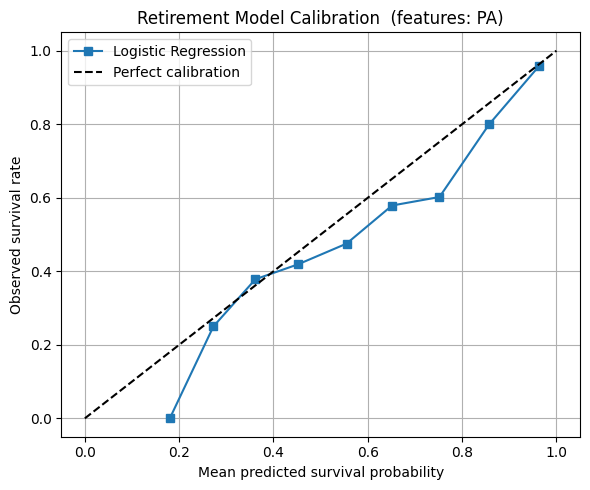


=== Baseline G Retirement Model (Def, Spd, WAR) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.7958   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1394  (lower = better; naive baseline = 0.1638)


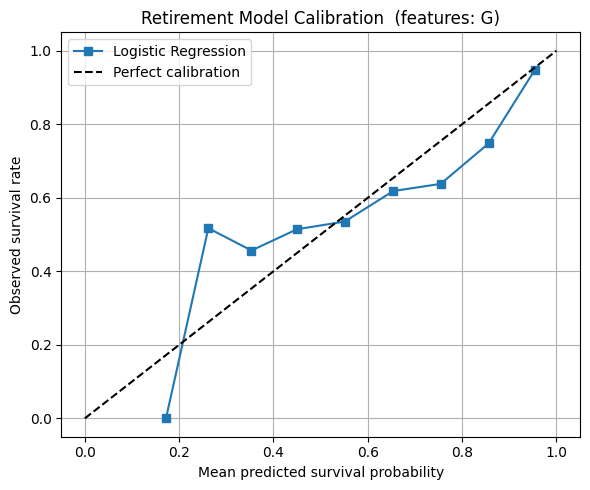

In [7]:
# Evaluate baseline retirement models (Age + weight_col + experience, no perf_col).
# These serve as a reference: compare the AUC here against the per-metric models
# trained with perf_col in each metric section below.
base_train, _ = load_data(target='wRC+')

print('=== Baseline PA Retirement Model (OPS, wRC+) ===')
evaluate_retirement_model(base_train, weight_col='PA')

print('\n=== Baseline G Retirement Model (Def, Spd, WAR) ===')
evaluate_retirement_model(base_train, weight_col='G')

## OPS Aging Curve

=== OPS Retirement Model (PA + OPS_centralized_lag) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.8329   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1278  (lower = better; naive baseline = 0.1638)


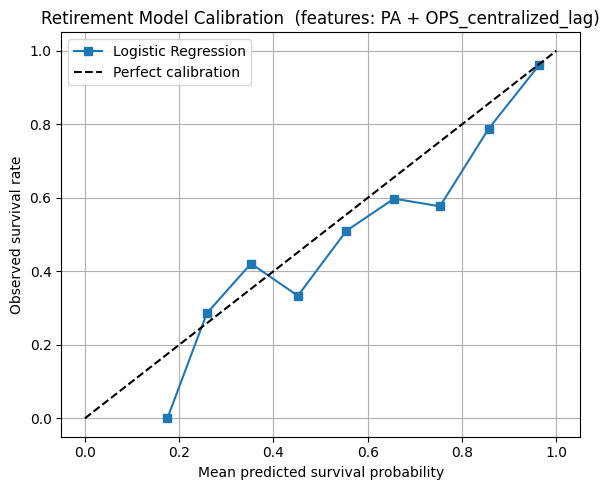


Mean survival probability by age (lower = stronger selection pressure):
Age
21    0.969
22    0.942
23    0.935
24    0.921
25    0.902
26    0.888
27    0.871
28    0.855
29    0.841
30    0.823
31    0.802
32    0.756
33    0.739
34    0.710
35    0.681
36    0.654
37    0.633
38    0.591
39    0.544
40    0.568


In [8]:
train_data, test_data = load_data(target='OPS', centralized=True)
ops_data = add_career_mean(train_data, 'OPS_centralized')

ops_retire_model, ops_retire_scaler = fit_retirement_model(
    ops_data, weight_col='PA', perf_col='OPS_centralized_lag')

print('=== OPS Retirement Model (PA + OPS_centralized_lag) ===')
evaluate_retirement_model(ops_data, weight_col='PA', perf_col='OPS_centralized_lag')

ops_ipw = compute_ipw_weights(
    ops_data, ops_retire_model, ops_retire_scaler,
    weight_col='PA', perf_col='OPS_centralized_lag')

print('\nMean survival probability by age (lower = stronger selection pressure):')
print(ops_ipw.groupby('Age')['p_survive'].mean().round(3).to_string())

In [9]:
features = ['Age', 'OPS_centralized_career_mean', 'experience', 'OPS_centralized_lag']
target   = 'OPS_centralized'
x, y = generate_data(ops_data, features, target)

gam_orig = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_orig.gridsearch(x, y, weights=ops_data['PA'].values, lam=np.logspace(-2, 3, 20))

gam_ipw = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_ipw.gridsearch(x, y, weights=ops_ipw['ipw_final_weight'].values, lam=np.logspace(-2, 3, 20))

100% (20 of 20) |########################| Elapsed Time: 0:00:05 Time:  0:00:05
100% (20 of 20) |########################| Elapsed Time: 0:00:06 Time:  0:00:06


GAM(callbacks=[Deviance(), Diffs()], distribution=NormalDist(), 
   fit_intercept=True, link=IdentityLink(), max_iter=100, 
   terms=te(0, 2) + s(1) + s(3) + intercept, tol=0.0001, 
   verbose=False)

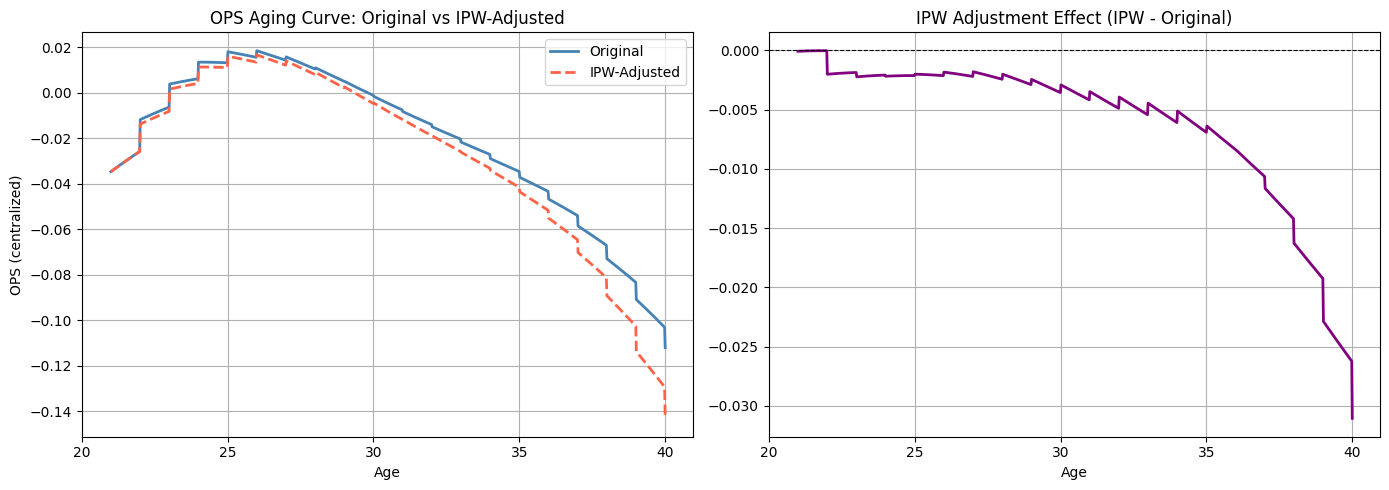

In [10]:
age_lag_means = ops_data.groupby('Age')['OPS_centralized_lag'].mean()

XX = gam_orig.generate_X_grid(term=0, n=1000)
XX[:, 2] = np.floor(XX[:, 0]) - 20.0
XX[:, 3] = [age_lag_means[int(np.floor(a))] for a in XX[:, 0]]

pred_orig = gam_orig.predict(XX)
pred_ipw  = gam_ipw.predict(XX)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(XX[:, 0], pred_orig, label='Original',     color='steelblue', linewidth=2)
axes[0].plot(XX[:, 0], pred_ipw,  label='IPW-Adjusted', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('OPS Aging Curve: Original vs IPW-Adjusted')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('OPS (centralized)')
axes[0].set_xticks(np.arange(20, 45, 5))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(XX[:, 0], pred_ipw - pred_orig, color='purple', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('IPW Adjustment Effect (IPW - Original)')
axes[1].set_xlabel('Age')
axes[1].set_xticks(np.arange(20, 45, 5))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
all_test_ops = generate_test_data(ops_data, test_data, 'OPS_centralized')
mae_orig = evaluate(all_test_ops, 'OPS_centralized', gam_orig)
mae_ipw  = evaluate(all_test_ops, 'OPS_centralized', gam_ipw)

peak_orig = XX[np.argmax(pred_orig), 0]
peak_ipw  = XX[np.argmax(pred_ipw),  0]

print(f'Peak Age  — Original: {peak_orig:.1f}  |  IPW-Adjusted: {peak_ipw:.1f}')
print(f'Test MAE  — Original: {mae_orig:.4f}  |  IPW-Adjusted: {mae_ipw:.4f}')

Peak Age  — Original: 26.0  |  IPW-Adjusted: 26.0
Test MAE  — Original: 0.0752  |  IPW-Adjusted: 0.0741


The OPS survival model (AUC = 0.833) is the strongest of all five metrics, but adding
`OPS_centralized_lag` as a feature barely improved it over the baseline (AUC 0.8328 → 0.8329).
This is expected: for hitting metrics, plate appearances already encode performance quality —
a hitter who posts poor OPS quickly loses playing time, so PA captures the same signal.

The IPW adjustment reduced test MAE from 0.0752 to 0.0741 (≈1.5% improvement), with the
peak age unchanged at 26. The right panel shows where survivorship bias was largest: the
downward adjustment at ages 33+ indicates that the original curve overstated how well
older hitters maintain their OPS, because only above-average hitters retain 100+ PA at
those ages.

## wRC+ Aging Curve

=== wRC+ Retirement Model (PA + wRC+_lag) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.8331   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1276  (lower = better; naive baseline = 0.1638)


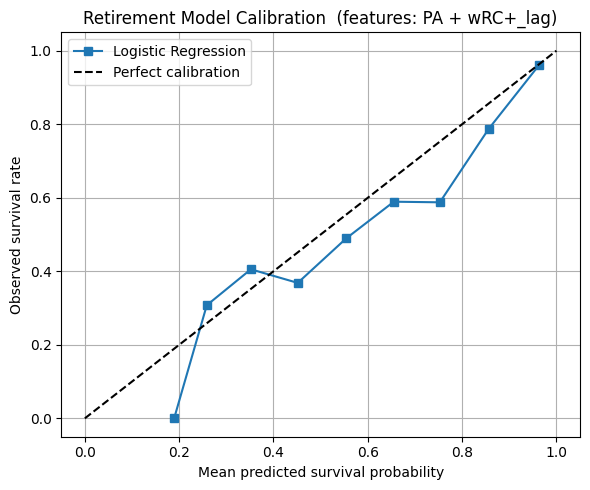


Mean survival probability by age:
Age
21    0.970
22    0.942
23    0.935
24    0.921
25    0.902
26    0.888
27    0.871
28    0.855
29    0.841
30    0.823
31    0.802
32    0.756
33    0.739
34    0.710
35    0.681
36    0.654
37    0.633
38    0.591
39    0.543
40    0.569


In [12]:
train_data, test_data = load_data(target='wRC+')
wrc_data = add_career_mean(train_data, 'wRC+')

wrc_retire_model, wrc_retire_scaler = fit_retirement_model(
    wrc_data, weight_col='PA', perf_col='wRC+_lag')

print('=== wRC+ Retirement Model (PA + wRC+_lag) ===')
evaluate_retirement_model(wrc_data, weight_col='PA', perf_col='wRC+_lag')

wrc_ipw = compute_ipw_weights(
    wrc_data, wrc_retire_model, wrc_retire_scaler,
    weight_col='PA', perf_col='wRC+_lag')

print('\nMean survival probability by age:')
print(wrc_ipw.groupby('Age')['p_survive'].mean().round(3).to_string())

In [13]:
features = ['Age', 'wRC+_career_mean', 'experience', 'wRC+_lag']
target   = 'wRC+'
x, y = generate_data(wrc_data, features, target)

gam_orig = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_orig.gridsearch(x, y, weights=wrc_data['PA'].values, lam=np.logspace(-2, 3, 20))

gam_ipw = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_ipw.gridsearch(x, y, weights=wrc_ipw['ipw_final_weight'].values, lam=np.logspace(-2, 3, 20))

100% (20 of 20) |########################| Elapsed Time: 0:00:04 Time:  0:00:04
100% (20 of 20) |########################| Elapsed Time: 0:00:04 Time:  0:00:04


GAM(callbacks=[Deviance(), Diffs()], distribution=NormalDist(), 
   fit_intercept=True, link=IdentityLink(), max_iter=100, 
   terms=te(0, 2) + s(1) + s(3) + intercept, tol=0.0001, 
   verbose=False)

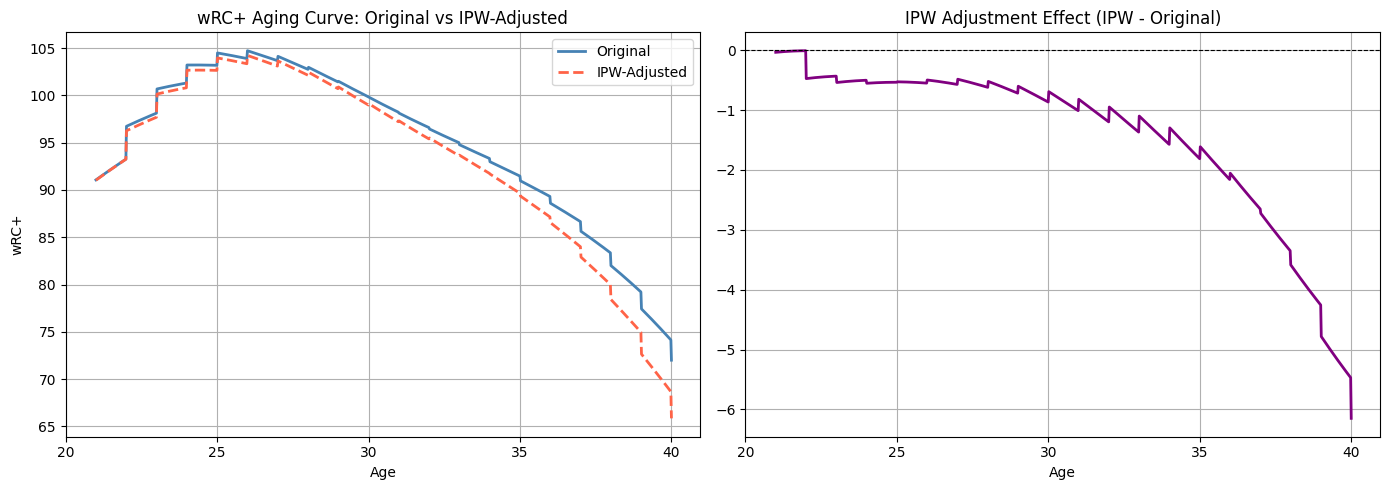

In [14]:
age_lag_means = wrc_data.groupby('Age')['wRC+_lag'].mean()

XX = gam_orig.generate_X_grid(term=0, n=1000)
XX[:, 1] = 100
XX[:, 2] = np.floor(XX[:, 0]) - 20.0
XX[:, 3] = [age_lag_means[int(np.floor(a))] for a in XX[:, 0]]

pred_orig = gam_orig.predict(XX)
pred_ipw  = gam_ipw.predict(XX)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(XX[:, 0], pred_orig, label='Original',     color='steelblue', linewidth=2)
axes[0].plot(XX[:, 0], pred_ipw,  label='IPW-Adjusted', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('wRC+ Aging Curve: Original vs IPW-Adjusted')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('wRC+')
axes[0].set_xticks(np.arange(20, 45, 5))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(XX[:, 0], pred_ipw - pred_orig, color='purple', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('IPW Adjustment Effect (IPW - Original)')
axes[1].set_xlabel('Age')
axes[1].set_xticks(np.arange(20, 45, 5))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
all_test_wrc = generate_test_data(wrc_data, test_data, 'wRC+')
mae_orig = evaluate(all_test_wrc, 'wRC+', gam_orig)
mae_ipw  = evaluate(all_test_wrc, 'wRC+', gam_ipw)

peak_orig = XX[np.argmax(pred_orig), 0]
peak_ipw  = XX[np.argmax(pred_ipw),  0]

print(f'Peak Age  — Original: {peak_orig:.1f}  |  IPW-Adjusted: {peak_ipw:.1f}')
print(f'Test MAE  — Original: {mae_orig:.4f}  |  IPW-Adjusted: {mae_ipw:.4f}')

Peak Age  — Original: 26.0  |  IPW-Adjusted: 26.0
Test MAE  — Original: 19.7154  |  IPW-Adjusted: 19.4684


Like OPS, adding `wRC+_lag` to the survival model had negligible effect on discrimination
(AUC 0.8328 → 0.8331). PA remains the dominant predictor — the 100 PA threshold acts as
a natural performance filter, making explicit performance features redundant for the
survival model.

The IPW adjustment reduced test MAE from 19.72 to 19.47 (≈1.3% improvement), consistent
with OPS. The peak age of 26 is stable across both curves. The downward correction at
older ages reflects positive selection: the wRC+ 100+ PA pool above age 33 is
disproportionately composed of elite hitters, overstating how typical players age.

## Def Aging Curve

=== Def Retirement Model (G + Def_lag) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.8006   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1378  (lower = better; naive baseline = 0.1638)


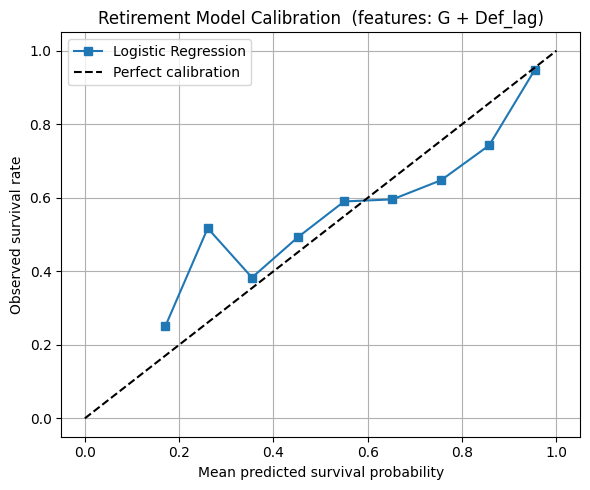


Mean survival probability by age:
Age
21    0.954
22    0.925
23    0.919
24    0.905
25    0.892
26    0.879
27    0.866
28    0.852
29    0.838
30    0.817
31    0.800
32    0.755
33    0.740
34    0.711
35    0.686
36    0.659
37    0.633
38    0.588
39    0.535
40    0.553


In [16]:
train_data, test_data = load_data(target='Def')
def_data = add_career_mean(train_data, 'Def')

def_retire_model, def_retire_scaler = fit_retirement_model(
    def_data, weight_col='G', perf_col='Def_lag')

print('=== Def Retirement Model (G + Def_lag) ===')
evaluate_retirement_model(def_data, weight_col='G', perf_col='Def_lag')

def_ipw = compute_ipw_weights(
    def_data, def_retire_model, def_retire_scaler,
    weight_col='G', perf_col='Def_lag')

print('\nMean survival probability by age:')
print(def_ipw.groupby('Age')['p_survive'].mean().round(3).to_string())

In [17]:
features = ['Age', 'Def_career_mean', 'experience', 'Def_lag']
target   = 'Def'
x, y = generate_data(def_data, features, target)

gam_orig = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_orig.gridsearch(x, y, weights=def_data['G'].values, lam=np.logspace(-2, 3, 20))

gam_ipw = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_ipw.gridsearch(x, y, weights=def_ipw['ipw_final_weight'].values, lam=np.logspace(-2, 3, 20))

100% (20 of 20) |########################| Elapsed Time: 0:00:04 Time:  0:00:04
100% (20 of 20) |########################| Elapsed Time: 0:00:04 Time:  0:00:04


GAM(callbacks=[Deviance(), Diffs()], distribution=NormalDist(), 
   fit_intercept=True, link=IdentityLink(), max_iter=100, 
   terms=te(0, 2) + s(1) + s(3) + intercept, tol=0.0001, 
   verbose=False)

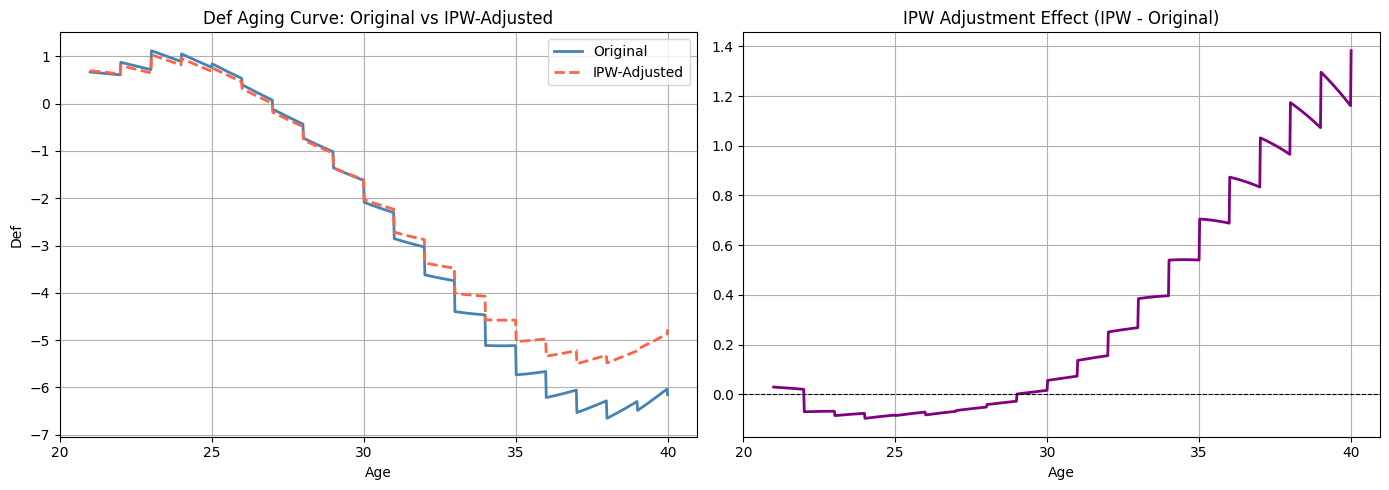

In [18]:
age_lag_means = def_data.groupby('Age')['Def_lag'].mean()

XX = gam_orig.generate_X_grid(term=0, n=1000)
XX[:, 1] = np.mean(def_data['Def'])
XX[:, 2] = np.floor(XX[:, 0]) - 20.0
XX[:, 3] = [age_lag_means[int(np.floor(a))] for a in XX[:, 0]]

pred_orig = gam_orig.predict(XX)
pred_ipw  = gam_ipw.predict(XX)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(XX[:, 0], pred_orig, label='Original',     color='steelblue', linewidth=2)
axes[0].plot(XX[:, 0], pred_ipw,  label='IPW-Adjusted', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Def Aging Curve: Original vs IPW-Adjusted')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Def')
axes[0].set_xticks(np.arange(20, 45, 5))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(XX[:, 0], pred_ipw - pred_orig, color='purple', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('IPW Adjustment Effect (IPW - Original)')
axes[1].set_xlabel('Age')
axes[1].set_xticks(np.arange(20, 45, 5))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [19]:
all_test_def = generate_test_data(def_data, test_data, 'Def')
mae_orig = evaluate(all_test_def, 'Def', gam_orig)
mae_ipw  = evaluate(all_test_def, 'Def', gam_ipw)

peak_orig = XX[np.argmax(pred_orig), 0]
peak_ipw  = XX[np.argmax(pred_ipw),  0]

print(f'Peak Age  — Original: {peak_orig:.1f}  |  IPW-Adjusted: {peak_ipw:.1f}')
print(f'Test MAE  — Original: {mae_orig:.4f}  |  IPW-Adjusted: {mae_ipw:.4f}')

Peak Age  — Original: 23.0  |  IPW-Adjusted: 23.0
Test MAE  — Original: 4.7541  |  IPW-Adjusted: 4.6579


Defensive ability peaks early (around age 23), driven primarily by athleticism that
deteriorates gradually throughout a career.

The metric-agnostic G model (AUC = 0.796) struggled here because games played is an
ambiguous signal for Def: a player with low G could be a declining defender being phased
out, or a defensive specialist who rarely bats. Adding `Def_lag` helped the model
distinguish these cases (AUC → 0.801), slightly improving IPW weight quality and
reducing test MAE from 4.754 to 4.658 (≈2.0% improvement).

The improvement is modest, however, because logistic regression cannot fully disentangle
position-specific effects from true defensive decline with the available features. A more
granular model incorporating position would likely improve both the survival model and
the IPW correction.

## Spd Aging Curve

=== Spd Retirement Model (G + Spd_lag) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.7955   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1396  (lower = better; naive baseline = 0.1638)


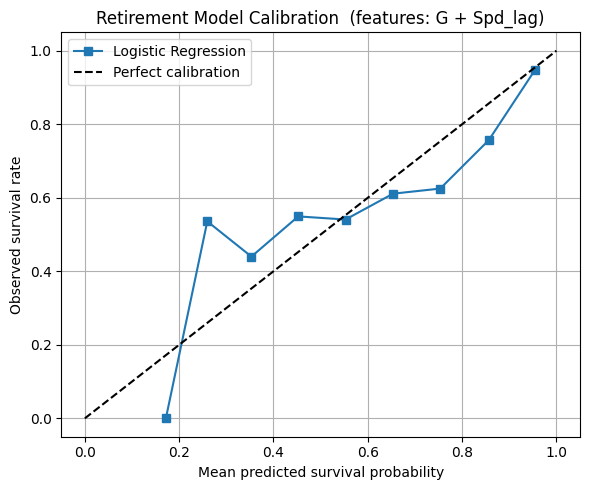


Mean survival probability by age:
Age
21    0.953
22    0.928
23    0.921
24    0.908
25    0.893
26    0.880
27    0.867
28    0.852
29    0.836
30    0.815
31    0.799
32    0.753
33    0.739
34    0.710
35    0.685
36    0.658
37    0.632
38    0.592
39    0.539
40    0.565


In [20]:
train_data, test_data = load_data(target='Spd')
spd_data = add_career_mean(train_data, 'Spd')

spd_retire_model, spd_retire_scaler = fit_retirement_model(
    spd_data, weight_col='G', perf_col='Spd_lag')

print('=== Spd Retirement Model (G + Spd_lag) ===')
evaluate_retirement_model(spd_data, weight_col='G', perf_col='Spd_lag')

spd_ipw = compute_ipw_weights(
    spd_data, spd_retire_model, spd_retire_scaler,
    weight_col='G', perf_col='Spd_lag')

print('\nMean survival probability by age:')
print(spd_ipw.groupby('Age')['p_survive'].mean().round(3).to_string())

In [21]:
features = ['Age', 'Spd_career_mean', 'experience', 'Spd_lag']
target   = 'Spd'
x, y = generate_data(spd_data, features, target)

gam_orig = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_orig.gridsearch(x, y, weights=spd_data['G'].values, lam=np.logspace(-2, 3, 20))

gam_ipw = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_ipw.gridsearch(x, y, weights=spd_ipw['ipw_final_weight'].values, lam=np.logspace(-2, 3, 20))

100% (20 of 20) |########################| Elapsed Time: 0:00:06 Time:  0:00:06
100% (20 of 20) |########################| Elapsed Time: 0:00:06 Time:  0:00:06


GAM(callbacks=[Deviance(), Diffs()], distribution=NormalDist(), 
   fit_intercept=True, link=IdentityLink(), max_iter=100, 
   terms=te(0, 2) + s(1) + s(3) + intercept, tol=0.0001, 
   verbose=False)

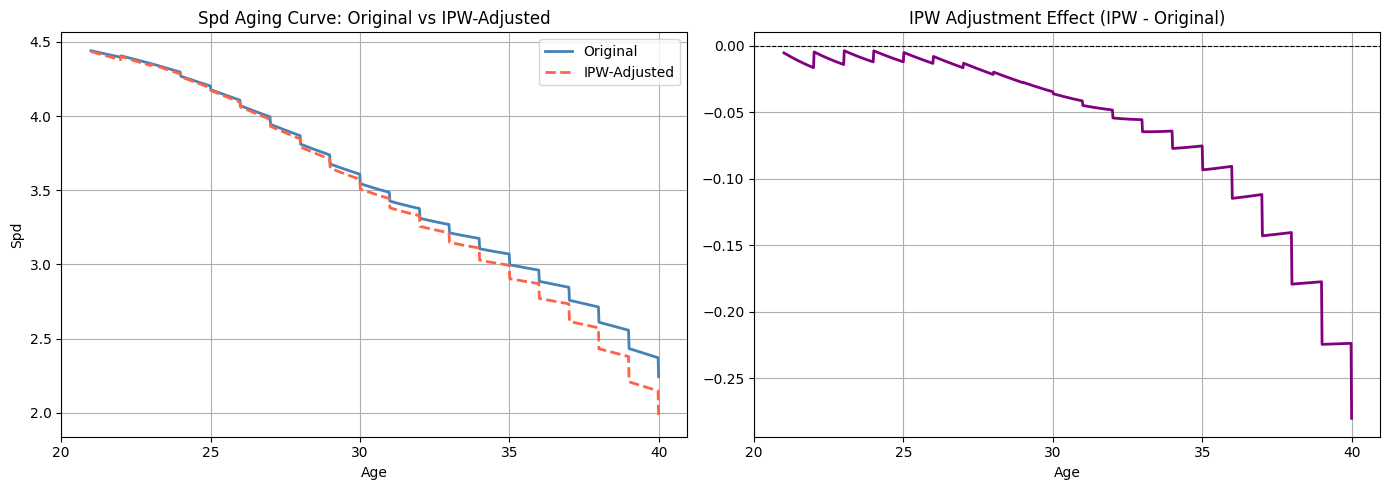

In [22]:
age_lag_means = spd_data.groupby('Age')['Spd_lag'].mean()

XX = gam_orig.generate_X_grid(term=0, n=1000)
XX[:, 1] = np.mean(spd_data['Spd'])
XX[:, 2] = np.floor(XX[:, 0]) - 20.0
XX[:, 3] = [age_lag_means[int(np.floor(a))] for a in XX[:, 0]]

pred_orig = gam_orig.predict(XX)
pred_ipw  = gam_ipw.predict(XX)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(XX[:, 0], pred_orig, label='Original',     color='steelblue', linewidth=2)
axes[0].plot(XX[:, 0], pred_ipw,  label='IPW-Adjusted', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Spd Aging Curve: Original vs IPW-Adjusted')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Spd')
axes[0].set_xticks(np.arange(20, 45, 5))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(XX[:, 0], pred_ipw - pred_orig, color='purple', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('IPW Adjustment Effect (IPW - Original)')
axes[1].set_xlabel('Age')
axes[1].set_xticks(np.arange(20, 45, 5))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
all_test_spd = generate_test_data(spd_data, test_data, 'Spd')
mae_orig = evaluate(all_test_spd, 'Spd', gam_orig)
mae_ipw  = evaluate(all_test_spd, 'Spd', gam_ipw)

peak_orig = XX[np.argmax(pred_orig), 0]
peak_ipw  = XX[np.argmax(pred_ipw),  0]

print(f'Peak Age  — Original: {peak_orig:.1f}  |  IPW-Adjusted: {peak_ipw:.1f}')
print(f'Test MAE  — Original: {mae_orig:.4f}  |  IPW-Adjusted: {mae_ipw:.4f}')

Peak Age  — Original: 21.0  |  IPW-Adjusted: 21.0
Test MAE  — Original: 0.9862  |  IPW-Adjusted: 0.9813


Speed peaks earliest of all metrics (age 21) and declines monotonically throughout a career.

Adding `Spd_lag` to the survival model had no effect (AUC 0.7958 → 0.7955), slightly
worse than the baseline. This suggests that games played (G) already captures the speed
signal well: slow players lose roster spots quickly, so the selection mechanism is largely
driven by playing time rather than a direct speed threshold. Including the lag adds noise
without useful information beyond what G provides.

IPW reduced test MAE from 0.986 to 0.981 (≈0.5% improvement), the smallest gain across
all five metrics. Speed decline is steep and consistent enough that survivorship bias
has a relatively minor distorting effect on the estimated curve shape.

## WAR Aging Curve

=== WAR Retirement Model (G + WAR_lag) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.8233   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1310  (lower = better; naive baseline = 0.1638)


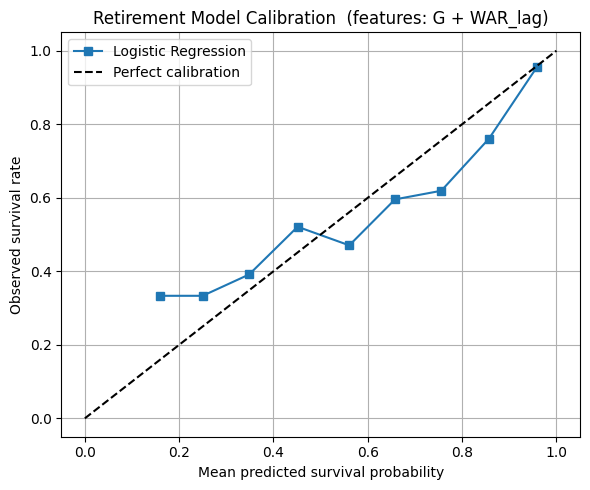


Mean survival probability by age:
Age
21    0.958
22    0.920
23    0.917
24    0.905
25    0.892
26    0.878
27    0.867
28    0.855
29    0.843
30    0.824
31    0.801
32    0.758
33    0.735
34    0.709
35    0.683
36    0.659
37    0.637
38    0.590
39    0.526
40    0.551


In [24]:
train_data, test_data = load_data(target='WAR')
war_data = add_career_mean(train_data, 'WAR')

war_retire_model, war_retire_scaler = fit_retirement_model(
    war_data, weight_col='G', perf_col='WAR_lag')

print('=== WAR Retirement Model (G + WAR_lag) ===')
evaluate_retirement_model(war_data, weight_col='G', perf_col='WAR_lag')

war_ipw = compute_ipw_weights(
    war_data, war_retire_model, war_retire_scaler,
    weight_col='G', perf_col='WAR_lag')

print('\nMean survival probability by age:')
print(war_ipw.groupby('Age')['p_survive'].mean().round(3).to_string())

In [25]:
features = ['Age', 'WAR_career_mean', 'experience', 'WAR_lag']
target   = 'WAR'
x, y = generate_data(war_data, features, target)

gam_orig = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_orig.gridsearch(x, y, weights=war_data['G'].values, lam=np.logspace(-2, 3, 20))

gam_ipw = GAM(te(0, 2, n_splines=5) + s(1, n_splines=5) + s(3, n_splines=5))
gam_ipw.gridsearch(x, y, weights=war_ipw['ipw_final_weight'].values, lam=np.logspace(-2, 3, 20))

100% (20 of 20) |########################| Elapsed Time: 0:00:06 Time:  0:00:06
100% (20 of 20) |########################| Elapsed Time: 0:00:06 Time:  0:00:06


GAM(callbacks=[Deviance(), Diffs()], distribution=NormalDist(), 
   fit_intercept=True, link=IdentityLink(), max_iter=100, 
   terms=te(0, 2) + s(1) + s(3) + intercept, tol=0.0001, 
   verbose=False)

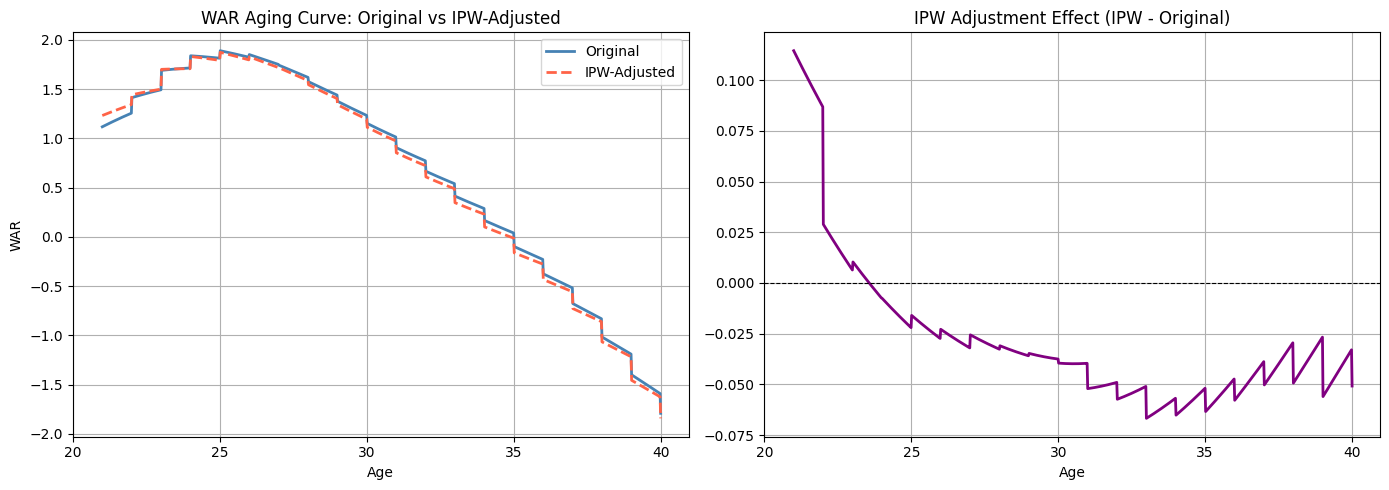

In [26]:
age_lag_means = war_data.groupby('Age')['WAR_lag'].mean()

XX = gam_orig.generate_X_grid(term=0, n=1000)
XX[:, 1] = np.mean(war_data['WAR'])
XX[:, 2] = np.floor(XX[:, 0]) - 20.0
XX[:, 3] = [age_lag_means[int(np.floor(a))] for a in XX[:, 0]]

pred_orig = gam_orig.predict(XX)
pred_ipw  = gam_ipw.predict(XX)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(XX[:, 0], pred_orig, label='Original',     color='steelblue', linewidth=2)
axes[0].plot(XX[:, 0], pred_ipw,  label='IPW-Adjusted', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('WAR Aging Curve: Original vs IPW-Adjusted')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('WAR')
axes[0].set_xticks(np.arange(20, 45, 5))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(XX[:, 0], pred_ipw - pred_orig, color='purple', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('IPW Adjustment Effect (IPW - Original)')
axes[1].set_xlabel('Age')
axes[1].set_xticks(np.arange(20, 45, 5))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
all_test_war = generate_test_data(war_data, test_data, 'WAR')
mae_orig = evaluate(all_test_war, 'WAR', gam_orig)
mae_ipw  = evaluate(all_test_war, 'WAR', gam_ipw)

peak_orig = XX[np.argmax(pred_orig), 0]
peak_ipw  = XX[np.argmax(pred_ipw),  0]

print(f'Peak Age  — Original: {peak_orig:.1f}  |  IPW-Adjusted: {peak_ipw:.1f}')
print(f'Test MAE  — Original: {mae_orig:.4f}  |  IPW-Adjusted: {mae_ipw:.4f}')

Peak Age  — Original: 25.0  |  IPW-Adjusted: 25.0
Test MAE  — Original: 1.4966  |  IPW-Adjusted: 1.4449


WAR is a composite metric integrating hitting, defense, and baserunning, and it showed the
largest benefit from adding `perf_col` to the survival model (AUC 0.7958 → 0.8233,
+0.028 — the biggest improvement across all five metrics).

This makes intuitive sense: games played (G) alone is a poor proxy for overall value.
A player can log 130+ games as a below-replacement utility player, or miss games due to
injury while being genuinely valuable. The lagged WAR directly captures overall contribution,
giving the survival model a much stronger signal for identifying players at retirement risk.

IPW reduced test MAE from 1.497 to 1.445 (≈3.5% improvement), the largest absolute
reduction of all metrics. The corrected curve better captures the steep decline in overall
value after the peak at age 25, reflecting the compounding of physical decline across all
three components of WAR.